In [1]:
print("AI-Powered CV Matching System")
print("Project Started Successfully!")

AI-Powered CV Matching System
Project Started Successfully!


In [46]:
!pip install -q pypdf
!pip install -q pdf2image
!pip install -q pytesseract
!pip install -q opencv-python
!pip install -q spacy
!pip install -q sentence-transformers
!pip install -q scikit-learn
!pip install -q gradio
!pip install -q pandas
!pip install -q matplotlib
!apt-get -qq install poppler-utils
!apt-get -qq install tesseract-ocr
!python -m spacy download en_core_web_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 75.1 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [48]:
import re
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pytesseract

from pypdf import PdfReader
from sklearn.metrics.pairwise import cosine_similarity
from pdf2image import convert_from_path


print("Libraries loaded successfully!")

Libraries loaded successfully!


In [4]:
from google.colab import files

uploaded = files.upload()

pdf_filename = list(uploaded.keys())[0]

print("Uploaded file:")
print(pdf_filename)

reader = PdfReader(pdf_filename)

print("Number of pages:", len(reader.pages))

Saving Mohamed_Hossam_CV_ATS.pdf to Mohamed_Hossam_CV_ATS.pdf
Uploaded file:
Mohamed_Hossam_CV_ATS.pdf
Number of pages: 1


In [5]:
raw_text = ""

for page in reader.pages:
    text = page.extract_text()

    if text:
        raw_text += text + "\n"

print(raw_text)

Mohamed Hossam Mohamed El-Sayed
Communications & Computer Engineering Student
Faqous, Sharqia, Egypt | +20 102 364 6671 | mg8666696@gmail.com
PROFILE
Communications and Computer Engineering student at Future University in Egypt, expected to graduate in 2027. Hands-
on experience in networking through Cisco CCNA, embedded systems, and practical field training. Able to design and 
build complete technical projects from concept to implementation, with strong skills in engineering software tools and 
programming.
EDUCATION
B.Sc. in Communications and Computer Engineering  —  Expected 2027
Future University in Egypt (FUE)
CERTIFICATIONS
Cisco CCNA: Introduction to Networks  —  Completed, August 15, 2026
Cisco Networking Academy
Cisco CCNA: Switching, Routing and Wireless Essentials  —  Completed, August 25, 2026
Cisco Networking Academy
Cisco CCNA: Enterprise Networking, Security and Automation  —  Completed, September 5, 2026
Cisco Networking Academy, delivered in collaboration with WE (Te

In [6]:
def clean_text(text):
    text = text.replace("\n", " ")
    text = re.sub(r"\s+", " ", text)
    return text.strip()

In [7]:
clean_cv_text = clean_text(raw_text)

print(clean_cv_text)

Mohamed Hossam Mohamed El-Sayed Communications & Computer Engineering Student Faqous, Sharqia, Egypt | +20 102 364 6671 | mg8666696@gmail.com PROFILE Communications and Computer Engineering student at Future University in Egypt, expected to graduate in 2027. Hands- on experience in networking through Cisco CCNA, embedded systems, and practical field training. Able to design and build complete technical projects from concept to implementation, with strong skills in engineering software tools and programming. EDUCATION B.Sc. in Communications and Computer Engineering — Expected 2027 Future University in Egypt (FUE) CERTIFICATIONS Cisco CCNA: Introduction to Networks — Completed, August 15, 2026 Cisco Networking Academy Cisco CCNA: Switching, Routing and Wireless Essentials — Completed, August 25, 2026 Cisco Networking Academy Cisco CCNA: Enterprise Networking, Security and Automation — Completed, September 5, 2026 Cisco Networking Academy, delivered in collaboration with WE (Telecom Egyp

In [8]:
cv_text_lower = clean_cv_text.lower()

print(cv_text_lower)

mohamed hossam mohamed el-sayed communications & computer engineering student faqous, sharqia, egypt | +20 102 364 6671 | mg8666696@gmail.com profile communications and computer engineering student at future university in egypt, expected to graduate in 2027. hands- on experience in networking through cisco ccna, embedded systems, and practical field training. able to design and build complete technical projects from concept to implementation, with strong skills in engineering software tools and programming. education b.sc. in communications and computer engineering — expected 2027 future university in egypt (fue) certifications cisco ccna: introduction to networks — completed, august 15, 2026 cisco networking academy cisco ccna: switching, routing and wireless essentials — completed, august 25, 2026 cisco networking academy cisco ccna: enterprise networking, security and automation — completed, september 5, 2026 cisco networking academy, delivered in collaboration with we (telecom egyp

In [9]:
if len(clean_cv_text) > 50:
    print("✅ CV text extracted successfully!")
else:
    print("⚠️ Very little text detected. OCR may be required.")

✅ CV text extracted successfully!


In [10]:
pages = convert_from_path(pdf_filename)

print("Pages converted:", len(pages))

Pages converted: 1


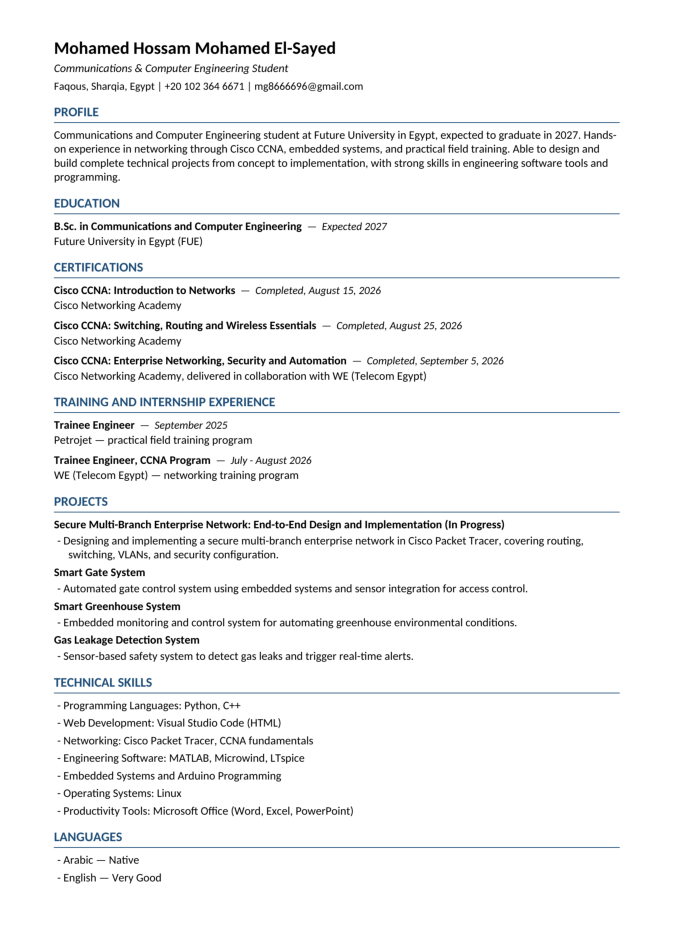

In [11]:
first_page = np.array(pages[0])

plt.figure(figsize=(10, 12))
plt.imshow(first_page)
plt.axis("off")
plt.show()

In [12]:
gray = cv2.cvtColor(first_page, cv2.COLOR_RGB2GRAY)

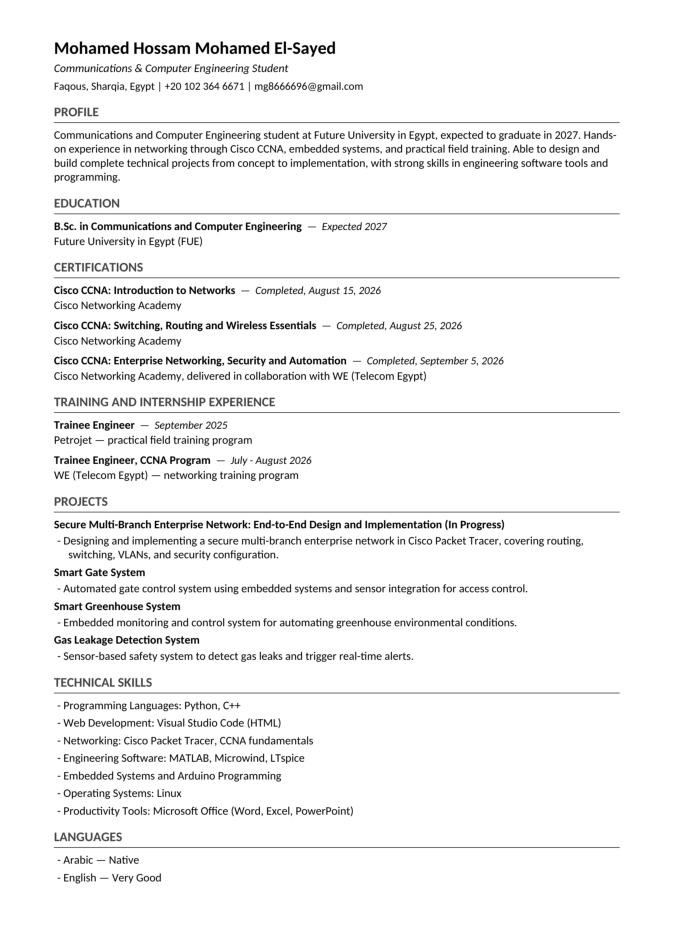

In [13]:
plt.figure(figsize=(10, 12))
plt.imshow(gray, cmap="gray")
plt.axis("off")
plt.show()

In [14]:
_, threshold = cv2.threshold(
    gray,
    0,
    255,
    cv2.THRESH_BINARY + cv2.THRESH_OTSU
)

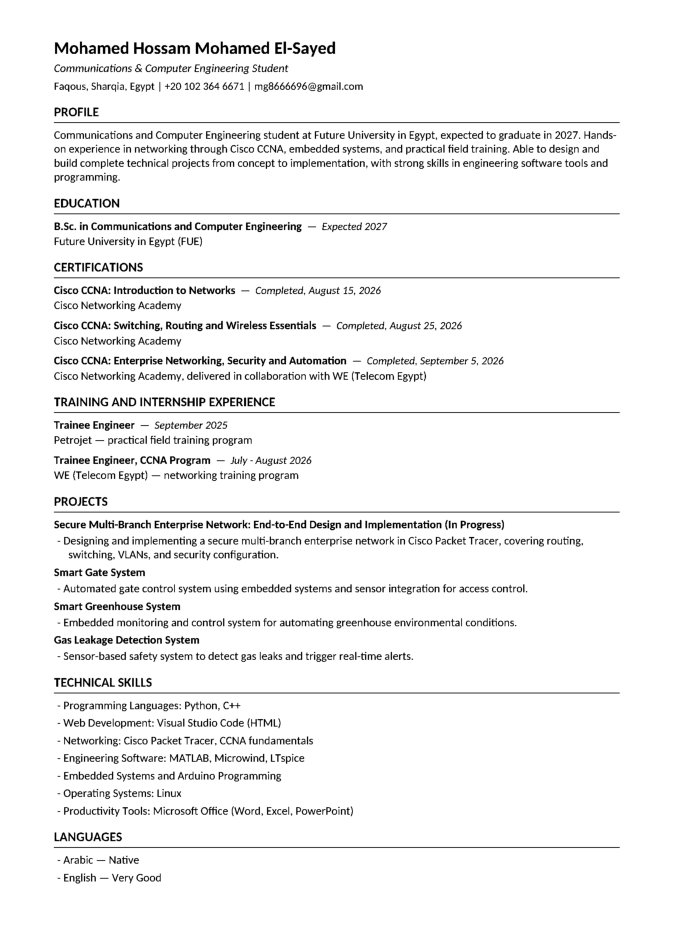

In [15]:
plt.figure(figsize=(10, 12))
plt.imshow(threshold, cmap="gray")
plt.axis("off")
plt.show()

In [16]:
ocr_text = pytesseract.image_to_string(threshold)

print(ocr_text)

Mohamed Hossam Mohamed El-Sayed
Communications & Computer Engineering Student
Faqous, Sharqia, Egypt | +20 102 364 6671 | mg8666696@gmail.com

PROFILE

Communications and Computer Engineering student at Future University in Egypt, expected to graduate in 2027. Hands-
on experience in networking through Cisco CCNA, embedded systems, and practical field training. Able to design and
build complete technical projects from concept to implementation, with strong skills in engineering software tools and
programming.

EDUCATION

B.Sc. in Communications and Computer Engineering — Expected 2027
Future University in Egypt (FUE)

CERTIFICATIONS

Cisco CCNA: Introduction to Networks — Completed, August 15, 2026
Cisco Networking Academy

Cisco CCNA: Switching, Routing and Wireless Essentials — Completed, August 25, 2026
Cisco Networking Academy

Cisco CCNA: Enterprise Networking, Security and Automation — Completed, September 5, 2026
Cisco Networking Academy, delivered in collaboration with WE (Tele

In [17]:
import spacy

nlp = spacy.load("en_core_web_sm")

In [18]:
doc = nlp(clean_cv_text)

In [19]:
for token in doc:
    print(token.text)

Mohamed
Hossam
Mohamed
El
-
Sayed
Communications
&
Computer
Engineering
Student
Faqous
,
Sharqia
,
Egypt
|
+20
102
364
6671
|
mg8666696@gmail.com
PROFILE
Communications
and
Computer
Engineering
student
at
Future
University
in
Egypt
,
expected
to
graduate
in
2027
.
Hands-
on
experience
in
networking
through
Cisco
CCNA
,
embedded
systems
,
and
practical
field
training
.
Able
to
design
and
build
complete
technical
projects
from
concept
to
implementation
,
with
strong
skills
in
engineering
software
tools
and
programming
.
EDUCATION
B.Sc
.
in
Communications
and
Computer
Engineering
—
Expected
2027
Future
University
in
Egypt
(
FUE
)
CERTIFICATIONS
Cisco
CCNA
:
Introduction
to
Networks
—
Completed
,
August
15
,
2026
Cisco
Networking
Academy
Cisco
CCNA
:
Switching
,
Routing
and
Wireless
Essentials
—
Completed
,
August
25
,
2026
Cisco
Networking
Academy
Cisco
CCNA
:
Enterprise
Networking
,
Security
and
Automation
—
Completed
,
September
5
,
2026
Cisco
Networking
Academy
,
delivered
in
collabora

In [21]:
found_skills = []

for skill in skills_database:
    if skill in cv_text_lower:
        found_skills.append(skill)

print("Detected Skills:")
print("----------------")

for skill in found_skills:
    print("✓", skill)

Detected Skills:
----------------
✓ python
✓ c++
✓ linux
✓ ccna
✓ networking
✓ cisco
✓ packet tracer
✓ routing
✓ switching
✓ vlan
✓ nat


In [22]:
emails = re.findall(
    r'\b[A-Za-z0-9._%+-]+@[A-Za-z0-9.-]+\.[A-Za-z]{2,}\b',
    clean_cv_text
)

print("Emails:", emails)

Emails: ['mg8666696@gmail.com']


In [23]:
phones = re.findall(
    r'(?<!\d)(?:\+?\d[\d\s\-()]{7,}\d)(?!\d)',
    clean_cv_text
)

print("Phones:", phones)

Phones: ['+20 102 364 6671']


In [24]:
for ent in doc.ents:
    print(ent.text, "->", ent.label_)

Mohamed Hossam Mohamed El-Sayed Communications & Computer -> PERSON
Sharqia -> GPE
Egypt -> GPE
PROFILE Communications -> ORG
Computer Engineering -> ORG
Future University -> ORG
Egypt -> GPE
2027 -> DATE
Cisco -> GPE
Communications -> ORG
Computer Engineering -> ORG
2027 -> DATE
Future University -> ORG
Egypt -> GPE
FUE -> ORG
CERTIFICATIONS -> ORG
August 15, 2026 -> DATE
Cisco Networking Academy -> ORG
Routing and Wireless Essentials — Completed -> WORK_OF_ART
August 25 -> DATE
2026 -> DATE
Cisco Networking Academy -> ORG
September 5 -> DATE
2026 -> DATE
Cisco Networking Academy -> ORG
Telecom -> GPE
Egypt -> GPE
INTERNSHIP -> ORG
September 2025 -> DATE
Petrojet -> GPE
Trainee Engineer -> ORG
July - August 2026 -> DATE
Telecom -> GPE
Egypt -> GPE
PROJECTS Secure Multi-Branch Enterprise Network -> ORG
Cisco -> GPE
Smart Gate System - Automated -> ORG
Smart Greenhouse System - Embedded -> ORG
TECHNICAL SKILLS - Programming Languages: Python -> ORG
C++ - Web Development -> PERSON
LTspic

In [25]:
job_description = """
Junior Network Engineer

Requirements:
CCNA
Networking
Routing
Switching
VLAN
OSPF
Linux
Python
BGP
Cloud Networking
Network Security
"""

In [26]:
job_text_lower = clean_text(job_description).lower()

print(job_text_lower)

junior network engineer requirements: ccna networking routing switching vlan ospf linux python bgp cloud networking network security


In [27]:
job_skills = []

for skill in skills_database:
    if skill in job_text_lower:
        job_skills.append(skill)

print("Job Skills:")
print("-----------")

for skill in job_skills:
    print("•", skill)

Job Skills:
-----------
• python
• linux
• ccna
• networking
• routing
• switching
• vlan
• ospf
• bgp
• network security
• cloud


In [28]:
matched_skills = []

for skill in job_skills:
    if skill in found_skills:
        matched_skills.append(skill)

print("Matched Skills:")
for skill in matched_skills:
    print("✓", skill)

Matched Skills:
✓ python
✓ linux
✓ ccna
✓ networking
✓ routing
✓ switching
✓ vlan


In [29]:
missing_skills = []

for skill in job_skills:
    if skill not in found_skills:
        missing_skills.append(skill)

print("Missing Skills:")
for skill in missing_skills:
    print("✗", skill)

Missing Skills:
✗ ospf
✗ bgp
✗ network security
✗ cloud


In [30]:
if len(job_skills) > 0:
    match_score = (len(matched_skills) / len(job_skills)) * 100
else:
    match_score = 0

print(f"Match Score: {match_score:.2f}%")

Match Score: 63.64%


In [31]:
from sentence_transformers import SentenceTransformer

model = SentenceTransformer("all-MiniLM-L6-v2")

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [32]:
cv_embedding = model.encode(clean_cv_text)
job_embedding = model.encode(job_description)

In [33]:
semantic_score = cosine_similarity(
    [cv_embedding],
    [job_embedding]
)[0][0]

print(f"Semantic Similarity: {semantic_score:.2%}")

Semantic Similarity: 50.27%


In [34]:
summary = f"""
The candidate has demonstrated skills in:
{", ".join(found_skills)}.

The candidate matches {len(matched_skills)}
out of {len(job_skills)} required skills for the target position.
"""

print(summary)


The candidate has demonstrated skills in:
python, c++, linux, ccna, networking, cisco, packet tracer, routing, switching, vlan, nat.

The candidate matches 7
out of 11 required skills for the target position.



In [35]:
recommendations = []

for skill in missing_skills:
    recommendations.append(
        f"Consider learning or improving {skill}."
    )

print("Recommendations:")
for recommendation in recommendations:
    print("•", recommendation)

Recommendations:
• Consider learning or improving ospf.
• Consider learning or improving bgp.
• Consider learning or improving network security.
• Consider learning or improving cloud.


In [36]:
interview_questions = {
    "ccna": "What topics are covered by the CCNA certification?",
    "ospf": "How does OSPF select the best path?",
    "vlan": "What is a VLAN and why is it used?",
    "linux": "What are some common Linux networking commands?",
    "python": "How can Python be used in networking?",
    "routing": "What is the difference between static and dynamic routing?",
    "switching": "What is the difference between a switch and a router?",
    "network security": "What are common techniques used to secure a network?"
}

In [37]:
print("Potential Interview Questions:")
print("--------------------------------")

for skill in found_skills:
    if skill in interview_questions:
        print("•", interview_questions[skill])

Potential Interview Questions:
--------------------------------
• How can Python be used in networking?
• What are some common Linux networking commands?
• What topics are covered by the CCNA certification?
• What is the difference between static and dynamic routing?
• What is the difference between a switch and a router?
• What is a VLAN and why is it used?


In [38]:
print("=" * 50)
print("          AI-Powered CV Matching System ")
print("=" * 50)

print("\nDetected Skills:")
for skill in found_skills:
    print("✓", skill)

print("\nMatched Skills:")
for skill in matched_skills:
    print("✓", skill)

print("\nMissing Skills:")
for skill in missing_skills:
    print("✗", skill)

print(f"\nMatch Score: {match_score:.2f}%")
print(f"Semantic Similarity: {semantic_score:.2%}")

print("\nRecommendations:")
for recommendation in recommendations:
    print("•", recommendation)

print("\nInterview Questions:")
for skill in found_skills:
    if skill in interview_questions:
        print("•", interview_questions[skill])

print("\n" + "=" * 50)

          AI-Powered CV Matching System 

Detected Skills:
✓ python
✓ c++
✓ linux
✓ ccna
✓ networking
✓ cisco
✓ packet tracer
✓ routing
✓ switching
✓ vlan
✓ nat

Matched Skills:
✓ python
✓ linux
✓ ccna
✓ networking
✓ routing
✓ switching
✓ vlan

Missing Skills:
✗ ospf
✗ bgp
✗ network security
✗ cloud

Match Score: 63.64%
Semantic Similarity: 50.27%

Recommendations:
• Consider learning or improving ospf.
• Consider learning or improving bgp.
• Consider learning or improving network security.
• Consider learning or improving cloud.

Interview Questions:
• How can Python be used in networking?
• What are some common Linux networking commands?
• What topics are covered by the CCNA certification?
• What is the difference between static and dynamic routing?
• What is the difference between a switch and a router?
• What is a VLAN and why is it used?



In [39]:
results = pd.DataFrame({
    "Skill": job_skills,
    "Status": [
        "Matched" if skill in matched_skills else "Missing"
        for skill in job_skills
    ]
})

results

,Skill,Status
0,python,Matched
1,linux,Matched
2,ccna,Matched
3,networking,Matched
4,routing,Matched
5,switching,Matched
6,vlan,Matched
7,ospf,Missing
8,bgp,Missing
9,network security,Missing


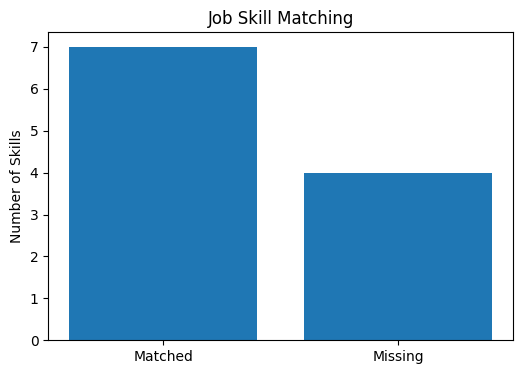

In [40]:
matched_count = len(matched_skills)
missing_count = len(missing_skills)

plt.figure(figsize=(6, 4))

plt.bar(
    ["Matched", "Missing"],
    [matched_count, missing_count]
)

plt.title("Job Skill Matching")
plt.ylabel("Number of Skills")

plt.show()

In [42]:
skills_database = [
    "python", "java", "c++", "linux", "windows", "ccna", "ccnp",
    "networking", "cisco", "packet tracer", "routing", "switching",
    "vlan", "ospf", "bgp", "dhcp", "dns", "nat", "acl", "tcp/ip",
    "network security", "cloud", "aws", "azure", "docker", "git",
    "sql", "machine learning", "deep learning", "computer vision",
    "opencv", "nlp"
]

In [43]:
import smtplib
from email.mime.text import MIMEText
from email.mime.multipart import MIMEMultipart
from email.header import Header
from email.utils import formataddr

# ❤لا بوابة الوصول بالإكابال المباشر (App Password)
SENDER_EMAIL = "academicweapon47@gmail.com"
SENDER_PASSWORD = "jzpq pecc fveb wbwf"  # الـ App Password (16 الإنابة بالإكابال الإنابة بالإكابال المباشر)


def extract_email(text):
    found = re.findall(
        r'\b[A-Za-z0-9._%+-]+@[A-Za-z0-9.-]+\.[A-Za-z]{2,}\b',
        text
    )
    return found[0] if found else None


def send_decision_email(to_email, subject, body,
                         smtp_server="smtp.gmail.com", smtp_port=587):

    if not to_email:
        return "☑ل الرابط الإنابة بالإكابال المباشر."

    msg = MIMEMultipart()
    msg["From"] = formataddr((str(Header(SENDER_EMAIL, "utf-8")), SENDER_EMAIL))
    msg["To"] = to_email
    msg["Subject"] = Header(subject, "utf-8")

    msg.attach(MIMEText(body, "plain", "utf-8"))

    try:
        server = smtplib.SMTP(smtp_server, smtp_port)
        server.starttls()
        server.login(SENDER_EMAIL, SENDER_PASSWORD)
        server.sendmail(SENDER_EMAIL, to_email, msg.as_string().encode("utf-8"))
        server.quit()
        return f"✅ الرابط الإنابة بالإكابال المباشر."
    except smtplib.SMTPAuthenticationError:
        return "❃ل الرابط الإنابة بالإكابال المباشر الرابط الإنابة بالإكابال المباشر."
    except Exception as e:
        return f"❃ل الرابط الإنابة بالإكابال المباشر."

In [44]:
def analyze_resume(pdf_file, job_description):   # <-- من غير sender_email, sender_password

    # 1. Read CV PDF
    reader = PdfReader(pdf_file)
    raw_text = ""
    for page in reader.pages:
        text = page.extract_text()
        if text:
            raw_text += text + "\n"

    # 2. Clean CV Text
    clean_cv_text = clean_text(raw_text)
    cv_text_lower = clean_cv_text.lower()

    # 3. Extract candidate email
    candidate_email = extract_email(clean_cv_text)

    # 4. Extract Skills from CV
    found_skills = []
    for skill in skills_database:
        if skill.lower() in cv_text_lower:
            found_skills.append(skill)

    # 5. Extract Skills from Job
    job_text_lower = clean_text(job_description).lower()
    job_skills = []
    for skill in skills_database:
        if skill.lower() in job_text_lower:
            job_skills.append(skill)

    # 6. Compare Skills
    matched_skills = [skill for skill in job_skills if skill in found_skills]
    missing_skills = [skill for skill in job_skills if skill not in found_skills]

    # 7. Calculate Match Score
    if len(job_skills) > 0:
        match_score = (len(matched_skills) / len(job_skills)) * 100
    else:
        match_score = 0

    # 8. Final Decision
    if match_score >= 70:
        status = "✅ SUITABLE FOR THIS POSITION"
        email_subject = "نتيجة التقديم: تم قبولك"
        final_decision = """
✨ CONGRATULATIONS!

You are ACCEPTED for this position.

Your profile is a strong match for the job requirements.

Good luck in your next step! 🚀
"""
    else:
        status = "❌ NOT SUITABLE FOR THIS POSITION"
        email_subject = "تحديث بخصوص طلب التقديم"
        final_decision = """
❌ Unfortunately...

You are NOT the candidate we are looking for.

Your current profile does not sufficiently match
the requirements of this position.

Keep improving and try again! 💪
"""

    # 9. Send Email Automatically (من غير باراميترات sender)
    email_status = send_decision_email(
        to_email=candidate_email,
        subject=email_subject,
        body=final_decision
    )

    # 10. Build Final Result
    result = f"""
AI RESUME ANALYZER
==============================

Candidate Email: {candidate_email if candidate_email else "Not Found"}
Match Score: {match_score:.1f}%

Status:
{status}

Matched Skills:
"""
    if matched_skills:
        for skill in matched_skills:
            result += f"✓ {skill}\n"
    else:
        result += "None\n"

    result += "\nMissing Skills:\n"
    if missing_skills:
        for skill in missing_skills:
            result += f"✗ {skill}\n"
    else:
        result += "None\n"

    result += f"""
==============================
FINAL DECISION
==============================
{final_decision}

==============================
EMAIL STATUS
==============================
{email_status}
"""

    return result

In [ ]:
import gradio as gr

demo = gr.Interface(
    fn=analyze_resume,
    inputs=[
        gr.File(
            label="📄 Upload CV PDF",
            file_types=[".pdf"],
            type="filepath"
        ),
        gr.Textbox(
            label="💼 Job Description",
            lines=12,
            placeholder="Enter the job description and requirements..."
        )
    ],
    outputs=gr.Textbox(
        label="🤖 AI Analysis Result",
        lines=40
    ),
    title="🤖 AI-Powered CV Matching System",
    description="""
Upload your CV and enter the Job Description.
The AI will analyze your CV, extract skills,
compare them with the job requirements,
calculate a match score, make a final decision,
and automatically email the result to the candidate.
"""
)

demo.launch(debug=True)

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://bb5bad9e0bddf397bf.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
